In [2]:
import numpy as np
import matplotlib.pyplot as plt 
import sounddevice as sd
import scipy.signal as signal
import numpy.linalg as lin
import scipy.linalg as linalg
from scipy.io import wavfile
from scipy.signal import tf2zpk
from scipy.signal import freqz
from scipy.signal import TransferFunction
from scipy.linalg import toeplitz
import pywt as wt
from scipy.fft import fft, fftfreq

# MSE StatDig : Chap 9 "Adaptive filtering"
## Ex 9.2 Linear prediction using RLS on non stationary process
ver : DLY/18.05.2026

## General

### Description

The goal of this exercice is to compare the LMS and the RLS algorithm for a one-step prediction of a non-stationary process.
Let $x[n]$ be a second-order autoregressive process AR(2) that is generated according to the difference equation:

$$
x[n] = -a_n[1] \cdot x[n-1] - a_n[2] \cdot x[n-2] + v[n] \\
$$

Where the coefficients $a_n[k]$ are changing accross time:

$$
\begin{cases} 
a_n[1] = -1.2728, a_n[2] = 0.81 \quad if \quad n \in [0, 99], \\
a_n[1] = 0, a_n[2] = 0.81 \quad if \quad n \in [100, 200], \\
\end{cases}
$$

Where $v[n]$ is a white Gaussian noise with variance $\sigma^2_v = 1$.

To remind, the scheme of a one-step prediction is:

![filter](src/LMS-91.png)

Therefore suppose we consider an adaptive linear predictor of the form:

$$\hat{x}[n] = w_n[1] x[n-1] + w_n[2] x[n-2]$$

The goal is to design the prediction using the two adaptive algorithms (RLS and LMS) and to compare the performance.


### Work

#### Ex1 : Signal generation

- Display the signals created by the following code as well the coefficients $a_n[k]$ used to generate the signal. :

```python
N = 500
x = np.zeros(N)
A = np.zeros((2, N))

aFirst = np.array([-1.2728, 0.81])
aSecond = np.array([0, 0.81])

np.random.seed(0)
v = np.random.randn(N) 

A[:, 0] = aFirst
A[:, 1] = aFirst

for n in range(2, N):
    if n <= 100:
        a = aFirst
    else:
        a = aSecond

    A[:, n] = a
    x[n] = -a[0] * x[n-1] - a[1] * x[n-2] + v[n]
```

In [3]:
N = 500
x = np.zeros(N)
A = np.zeros((2, N))

aFirst = np.array([-1.2728, 0.81])
aSecond = np.array([0, 0.81])

np.random.seed(0)
v = np.random.randn(N) 

A[:, 0] = aFirst
A[:, 1] = aFirst

for n in range(2, N):
    if n <= 100:
        a = aFirst
    else:
        a = aSecond

    A[:, n] = a
    x[n] = -a[0] * x[n-1] - a[1] * x[n-2] + v[n]

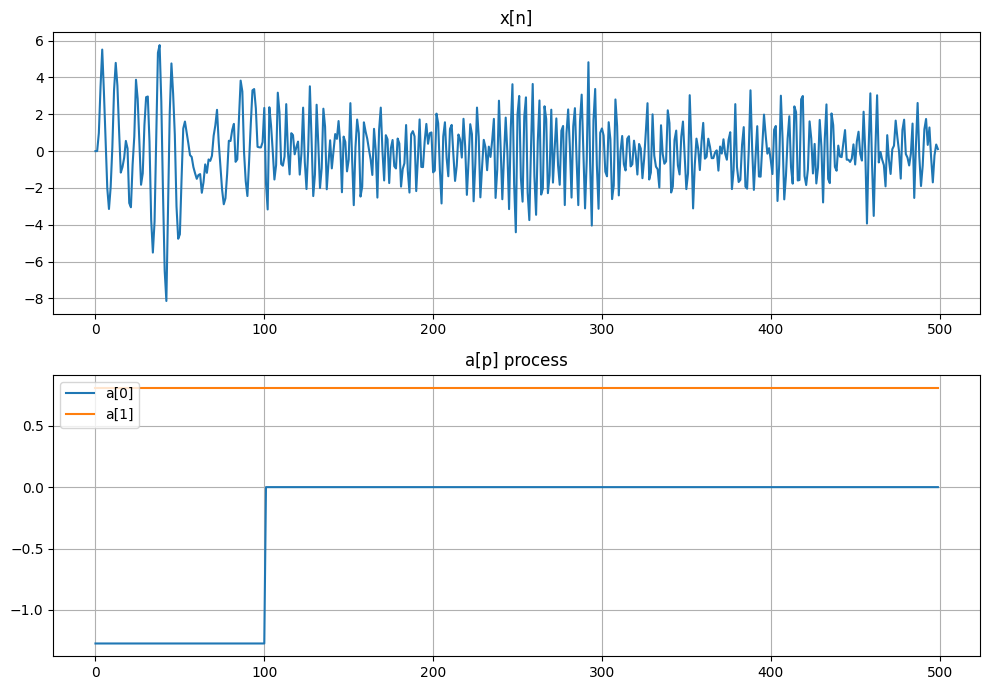

In [4]:
#Plot the signal
fig = plt.figure(figsize=(10, 7))
ax1 = fig.add_subplot(2, 1, 1)

ax1.plot(x)
ax1.set_title('x[n]')
ax1.grid(True)

ax2 = fig.add_subplot(2, 1, 2)

ax2.plot(A[0], label = 'a[0]')
ax2.plot(A[1], label = 'a[1]')
ax2.set_title('a[p] process')
ax2.legend(loc='upper left')
ax2.grid(True)

fig.tight_layout()
plt.show()

#### Ex2 : Adaptive filter 
##### Ex2.1 Recursive autocorrelation
As seen in theory, the RLS algorithm can be expressed by computing the weighted deterministic autocorrelation matrix for x[n] and the deterministic cross-correlation between d[n] and x[n].

$$
\bold{R}_x(n) \bold{w_n} = \bold{r}_{dx}(n)
$$

$$
\bold{w}_n = \bold{R}_x^{-1}(n) \cdot \bold{r}_{dx}(n)
$$

The deterministic autocorrelation is computed:

$$
\bold{R}_x(n) = \sum_{i=0}^{n} \lambda^{n-i} x[i] x^T[i] = \lambda \bold{R}_x(n - 1) + \bold{x}^*[n] \bold{x}^T[n]
$$

And the deterministic cross-correlation is computed:

$$
\bold{r}_{dx}(n) = \sum_{i=0}^{n} \lambda^{n-i} d[i] \bold{x}^*[i] = \lambda \bold{r}_{dx}(n - 1) + d[i] \bold{x}^T[i]
$$

Where $x[i]$ is the sample vector which contains the last p samples:

$$
\bold{x}[i] =
\begin{bmatrix}
x[i] \\
x[i-1] \\
\vdots \\
x[i - p]
\end{bmatrix}
$$

And for a predictive filter, the desired output $d[i]$ is simply the future sample:

$$
d[i] = x[i + 1]
$$

your work :

- Compute the deterministic autocorrelation matrix $\bold{R}_x(n)$ and the deterministic cross-correlation $\bold{r}_{dx}(n)$ using the above equations.
- Use the above equations to compute the filter coefficients $\bold{w}_n$ using the Wiener-Hopf equations.
- Compare the coefficients with the AR(2) coefficients.


In [5]:
p = 2
lamb = 0.98

Rx = np.zeros((p, p))
rdx = np.zeros(p)
w_n_vec = np.zeros((N, p))
for n in range(p, N-1):
    x_vec = x[n-p : n][::-1]
    d = x[n + 1]
    rdx = lamb*rdx + d * x_vec
    Rx = lamb*Rx + np.outer(x_vec, x_vec)
    w_n = np.linalg.pinv(Rx) @ rdx
    
    # On sauvegarde nos poids de l'instant présent
    w_n_vec[n] = w_n

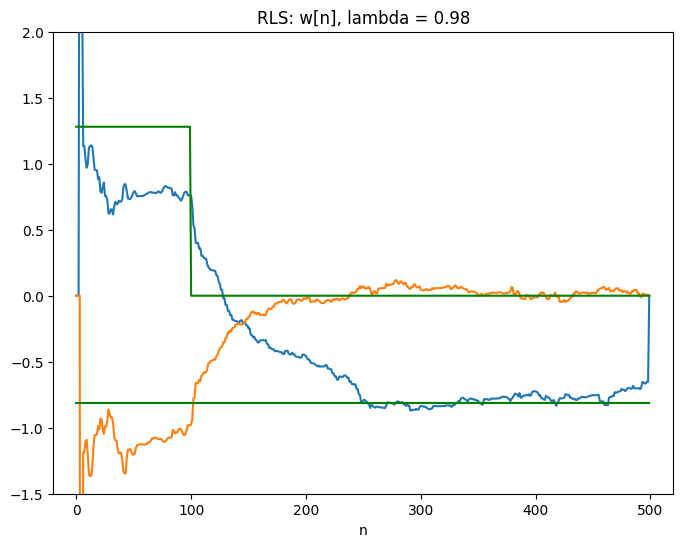

In [6]:
# Création de la figure
plt.figure(figsize=(8, 6))

# 1. Affichage de tes prédictions (Les lignes qui tremblent)
# w_historique[:, 0] prend toute la colonne du premier poids (bleu)
# w_historique[:, 1] prend toute la colonne du deuxième poids (orange)
plt.plot(w_n_vec[:, 0], label='w_1 estimé (Bleu)', color='tab:blue')
plt.plot(w_n_vec[:, 1], label='w_2 estimé (Orange)', color='tab:orange')

# 2. Affichage des vraies valeurs (Les lignes vertes)
# Normalement tu as ces vraies valeurs depuis la partie 1 de ton TP.
# Si tu ne les as pas dans un tableau, on peut les recréer artificiellement 
# basées sur ton image pour faire les lignes vertes :
vraies_valeurs_w1 = np.ones(N) * 1.28
vraies_valeurs_w1[100:] = 0.0  # La cassure à n=100

vraies_valeurs_w2 = np.ones(N) * -0.81

plt.plot(vraies_valeurs_w1, color='green', label='Vraies valeurs (Vert)')
plt.plot(vraies_valeurs_w2, color='green')


# 3. Paramètres visuels (pour que ça ressemble exactement à ta capture)
plt.title(f'RLS: w[n], lambda = {lamb}')
plt.xlabel('n')
plt.ylim(-1.5, 2.0)
plt.xlim(-20, 520) # Pour avoir un peu d'espace sur les bords

# Affiche le graphique
plt.show()

##### Ex2.2 Design RLS

To avoid this inverse of $\bold{R}_x(n)$  accross time, we could compute the inverse recursively as well. For that, you can use the RLS calculation given in the theory and implement the function `myRLS()`. Then, you can compare the found coefficients to the optimum coefficients. Use as previously  p = 2 and $\lambda=0.98$.

- Implement the function `myRLS()` and predict the signal x[n]

```python

def myRLS(x, d, p, lambda_):
    """
    Recursive Least Squares (RLS) adaptive filter.

    Parameters:
        x : (N,) ndarray
            Input data to the adaptive filter (1D array).
        d : (N,) ndarray
            Desired output (1D array).
        p : int
            Number of filter coefficients.
        lambda_ : float
            Exponential forgetting factor (typically close to 1, e.g., 0.98).

    Returns:
        W : (N,p) ndarray
            Filter coefficient matrix (each row is the filter at time n).
        e : (N,) ndarray
            Error sequence over time.
    """

    return W,e
    
    ```

In [7]:
def myRLS(x, d, p, lambda_):
    """
    Recursive Least Squares (RLS) adaptive filter.

    Parameters:
        x : (N,) ndarray
            Input data to the adaptive filter (1D array).
        d : (N,) ndarray
            Desired output (1D array).
        p : int
            Number of filter coefficients.
        lambda_ : float
            Exponential forgetting factor (typically close to 1, e.g., 0.98).

    Returns:
        W : (N,p) ndarray
            Filter coefficient matrix (each row is the filter at time n).
        e : (N,) ndarray
            Error sequence over time.
    """
    N = len(x)

    W = np.zeros((N, p))
    e = np.zeros(N)

    delta = 0.01
    P = np.eye(p) * (1 / delta)  # P[0] = delta^-1 * I
    w = np.zeros(p)              # w_0 = 0
    for n in range(p, N):
        x_vec = x[n-p : n][::-1]

        z = P @ x_vec
        
        g = z / (lambda_ + (x_vec @ z))
        
        alpha = d[n] - (w @ x_vec)
        
        w = w + (alpha * g)
        
        P = (P - np.outer(g, z)) / lambda_
        
        W[n] = w
        e[n] = alpha
        
    return W, e

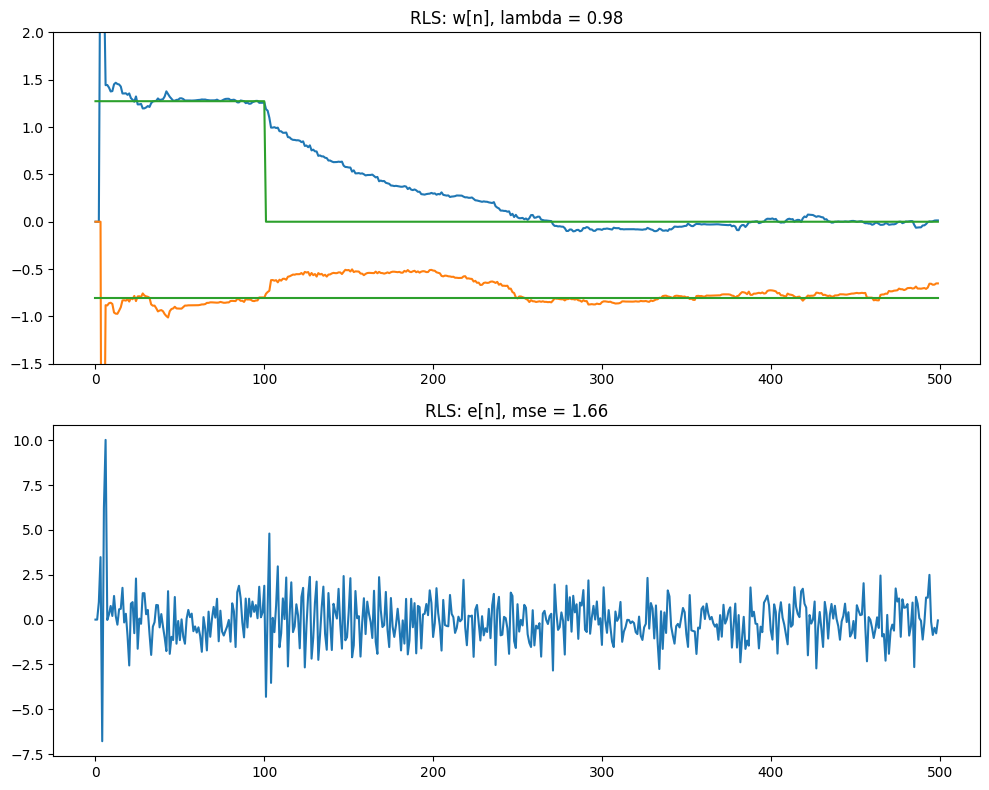

In [8]:
# --- Ex 2.2 : Test de la fonction myRLS et affichage ---

p = 2
lambda_ = 0.98

# 1. Exécution de ta fonction RLS
W_rls_seul, e_rls_seul = myRLS(x, x, p, lambda_)

# 2. Calcul du MSE (en ignorant le régime transitoire des p premiers échantillons)
mse_rls_seul = np.mean(e_rls_seul[p:]**2)

# 3. Création de la figure (correspond à ta première capture d'écran)
fig = plt.figure(figsize=(10, 8))

# --- Graphique 1 : Évolution des poids w[n] ---
ax1 = fig.add_subplot(2, 1, 1)

# Poids estimés par RLS (bleu et orange)
ax1.plot(W_rls_seul[:, 0], color='tab:blue')
ax1.plot(W_rls_seul[:, 1], color='tab:orange')

# Vraies valeurs (les lignes vertes) : w_opt = -a
true_w1 = -A[0, :]
true_w2 = -A[1, :]
ax1.plot(true_w1, color='tab:green')
ax1.plot(true_w2, color='tab:green')

ax1.set_title(f'RLS: w[n], lambda = {lambda_}')
ax1.set_ylim(-1.5, 2.0)

# --- Graphique 2 : Signal d'erreur e[n] ---
ax2 = fig.add_subplot(2, 1, 2)

ax2.plot(e_rls_seul, color='tab:blue')
ax2.set_title(f'RLS: e[n], mse = {mse_rls_seul:.2f}')

plt.tight_layout()
plt.show()

##### Ex2.3 Comparison with LMS

- Evaluate the prediction with the LMS algorithm by using your function `myLMS()`and the parameters $\mu = 0.02$.
- Plot the prediction and the error signal for both algorithms.


In [9]:
def myLMS(x, d, mu, p):
    """
    Filtre adaptatif LMS (rappel de l'exercice précédent)
    """
    N = len(x)
    w = np.zeros(p)
    e = np.zeros(N)
    W = np.zeros((N, p))

    for n in range(p, N):
        x_vec = x[n-p : n][::-1]
        d_hat = w @ x_vec
        e[n] = d[n] - d_hat
        w = w + mu * e[n] * x_vec
        W[n] = w
        
    return W, e

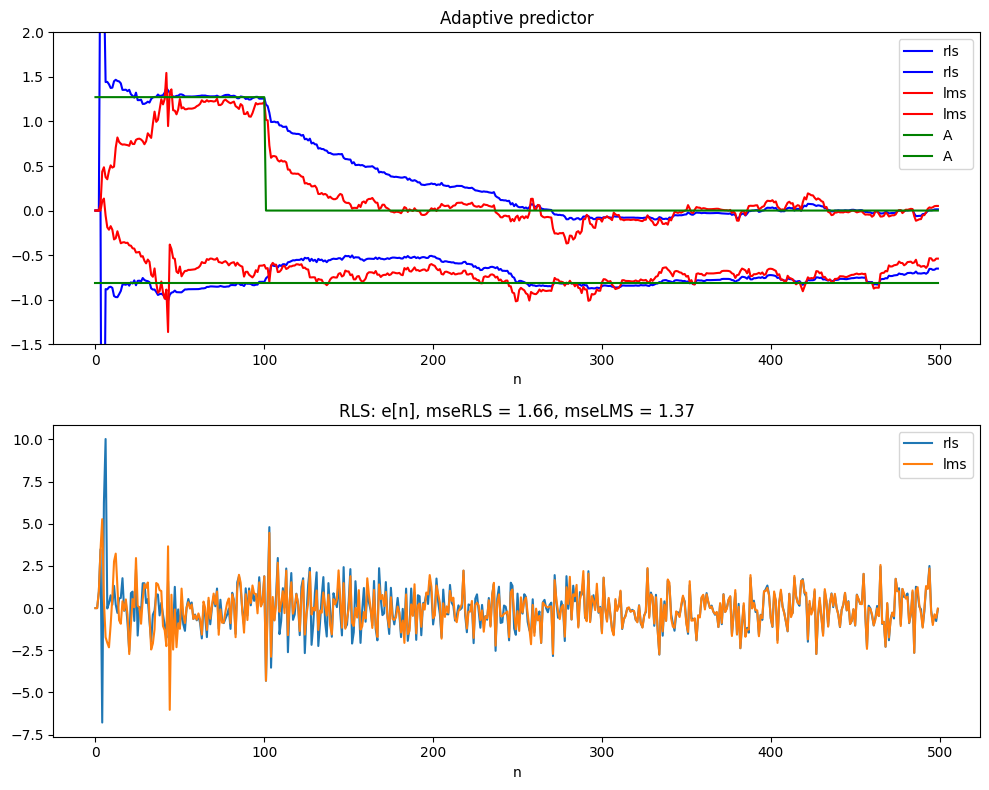

In [10]:
p = 2
lambda_ = 0.98
mu = 0.02

# Prédiction à 1 pas : le signal désiré d[n] est simplement x[n]
W_rls, e_rls = myRLS(x, x, p, lambda_)
W_lms, e_lms = myLMS(x, x, mu, p)

# Calcul des MSE (en ignorant les p premiers échantillons de transitoire)
mse_rls = np.mean(e_rls[p:]**2)
mse_lms = np.mean(e_lms[p:]**2)

# --- 3. Affichage des résultats (comme sur l'image) ---
fig = plt.figure(figsize=(10, 8))

# --- Graphique 1 : Comparaison des coefficients ---
ax1 = fig.add_subplot(2, 1, 1)

# RLS (en bleu)
ax1.plot(W_rls[:, 0], color='blue', label='rls')
ax1.plot(W_rls[:, 1], color='blue', label='rls')

# LMS (en rouge)
ax1.plot(W_lms[:, 0], color='red', label='lms')
ax1.plot(W_lms[:, 1], color='red', label='lms')

# Valeurs théoriques A (en vert)
# Rappel : x[n] = -a[1]*x[n-1] - a[2]*x[n-2], donc w_opt = -a
true_w1 = -A[0, :]
true_w2 = -A[1, :]
ax1.plot(true_w1, color='green', label='A')
ax1.plot(true_w2, color='green', label='A')

ax1.set_title('Adaptive predictor')
ax1.set_xlabel('n')
ax1.set_ylim(-1.5, 2.0)
ax1.legend(loc='upper right')

# --- Graphique 2 : Erreurs de prédiction ---
ax2 = fig.add_subplot(2, 1, 2)

# e[n] pour RLS (bleu) et LMS (orange)
ax2.plot(e_rls, color='tab:blue', label='rls')
ax2.plot(e_lms, color='tab:orange', label='lms')

ax2.set_title(f'RLS: e[n], mseRLS = {mse_rls:.2f}, mseLMS = {mse_lms:.2f}')
ax2.set_xlabel('n')
ax2.legend(loc='upper right')

plt.tight_layout()
plt.show()